# Domain Health Monitoring & AI Model Training

This notebook simulates domain health metrics, generates time-series health snapshots, and trains an anomaly detection model for Data Mesh monitoring. Follow the sections in order for reproducible results.

## 1. Import Required Libraries

In [85]:
import os
import glob
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.ensemble import IsolationForest
import joblib

## 2. Define Utility Functions

In [86]:
# Paths
DOMAINS_PATH = "../Data_Mesh_Domains"
HISTORY_PATH = "../monitoring/domain_health_history.csv"
MODEL_PATH = "../ml/domain_health_iforest.pkl"

# Utility: Get all domain CSVs (only allowed domains)
def get_domain_csvs(domains_path):
    pattern = os.path.join(domains_path, "*", "*.csv")
    all_csvs = glob.glob(pattern)
    allowed = [
        "engagement_domain",
        "Interaction_domain",
        "product_domain",
        "sales_domain",
        "shop_domain",
        "user_preferences_domain",
        "users_domain"
    ]
    filtered_csvs = [csv for csv in all_csvs if any(domain in csv for domain in allowed)]
    return filtered_csvs

def simulate_freshness():
    return round(np.random.uniform(0.5, 48), 2)

def simulate_schema_change():
    return np.random.choice([0, 1], p=[0.95, 0.05])

## 3. Simulate Metrics

In [87]:
# Example simulation
print("Simulated freshness (hours):", simulate_freshness())
print("Simulated schema change flag:", simulate_schema_change())

Simulated freshness (hours): 8.47
Simulated schema change flag: 0


## 4. Compute Domain Health Metrics

In [88]:
def compute_metrics(df):
    """Compute health metrics for a domain dataframe, with simulated variations."""
    row_count = len(df) + np.random.randint(-5, 6)
    null_percentage = round(df.isnull().mean().mean() * 100 + np.random.uniform(-1, 1), 2)
    duplicate_percentage = round((df.duplicated().mean() * 100) + np.random.uniform(-1, 1), 2)
    freshness_hours = simulate_freshness()
    schema_change_flag = simulate_schema_change()
    return {
        "row_count": max(row_count, 0),
        "null_percentage": max(null_percentage, 0),
        "duplicate_percentage": max(duplicate_percentage, 0),
        "freshness_hours": freshness_hours,
        "schema_change_flag": schema_change_flag
    }

## 8. Simulate Multiple Snapshot Generations with Different Dates
To build a rich time-series dataset, let's generate snapshots across simulated dates.

In [89]:
# 8A. Add Real Domain Health Snapshot Before Simulating Synthetic Data
import pandas as pd
import os
from datetime import datetime

# Path to shared health history file
HISTORY_PATH = "../monitoring/domain_health_history.csv"

# --- 1. Get the latest refresh timestamp from ReloadDataMeshDomains.ipynb output ---
# Use the timestamp from the most recent snapshot in Data_Mesh_Domains (from the last reload)
# We'll use the latest file modification time among all domain CSVs as the reload time

domain_dirs = [
    "engagement_domain",
    "Interaction_domain",
    "product_domain",
    "sales_domain",
    "shop_domain",
    "user_preferences_domain",
    "users_domain"
]

latest_mtime = 0
for domain_dir in domain_dirs:
    csv_path = os.path.join(DOMAINS_PATH, domain_dir, f"{domain_dir}.csv")
    if os.path.exists(csv_path):
        mtime = os.path.getmtime(csv_path)
        if mtime > latest_mtime:
            latest_mtime = mtime

if latest_mtime > 0:
    reload_time = datetime.fromtimestamp(latest_mtime).strftime("%Y-%m-%d %H:%M:%S")
else:
    reload_time = datetime.now().strftime("%Y-%m-%d %H:%M:%S")

# --- 2. Collect real snapshot from current Data Mesh Domains ---
real_records = []
for domain_dir in domain_dirs:
    csv_path = os.path.join(DOMAINS_PATH, domain_dir, f"{domain_dir}.csv")
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        metrics = compute_metrics(df)
        record = {
            "domain_name": domain_dir,
            **metrics,
            "timestamp": reload_time  # Use reload time from file modification
        }
        real_records.append(record)

real_df = pd.DataFrame(real_records)

# --- 3. Write/append real snapshot to file (write header if file does not exist) ---
if not real_df.empty:
    if not os.path.exists(HISTORY_PATH):
        real_df.to_csv(HISTORY_PATH, index=False)
    else:
        real_df.to_csv(HISTORY_PATH, mode="a", header=False, index=False)
    print(f"Real domain health snapshot written to {HISTORY_PATH} with timestamp {reload_time}")
else:
    print("No real domain health data found to write.")

Real domain health snapshot written to ../monitoring/domain_health_history.csv with timestamp 2026-01-05 00:22:51


In [90]:
from datetime import timedelta

def generate_snapshots_over_dates(num_days=10):
    base_date = datetime.now()
    for i in range(num_days):
        # Simulate date
        simulated_date = base_date - timedelta(days=num_days - i)
        # Generate snapshot with simulated timestamp
        domain_csvs = get_domain_csvs(DOMAINS_PATH)
        records = []
        for csv_path in domain_csvs:
            domain_name = os.path.basename(os.path.dirname(csv_path))
            df = pd.read_csv(csv_path)
            metrics = compute_metrics(df)
            record = {
                "domain_name": domain_name,
                **metrics,
                "timestamp": simulated_date.strftime("%Y-%m-%d %H:%M:%S")
            }
            records.append(record)
        df_records = pd.DataFrame(records)
        if os.path.exists(HISTORY_PATH):
            df_records.to_csv(HISTORY_PATH, mode="a", header=False, index=False)
        else:
            df_records.to_csv(HISTORY_PATH, mode="w", header=True, index=False)
        print(f"Appended {len(records)} domain health snapshots for {simulated_date.date()} to {HISTORY_PATH}")

generate_snapshots_over_dates(num_days=20)

Appended 7 domain health snapshots for 2025-12-17 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-18 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-19 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-20 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-21 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-22 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-23 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-24 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-25 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-26 to ../monitoring/domain_health_history.csv
Appended 7 domain health snapshots for 2025-12-27 to ../monitoring/dom

## 9. Preprocess Domain Health History
Clean and prepare the time-series data for model training and evaluation.

In [91]:
df = pd.read_csv(HISTORY_PATH)
# Remove duplicates, handle missing values, sort by timestamp
df = df.drop_duplicates()
df = df.fillna(0)
df = df.sort_values(by=["domain_name", "timestamp"])
print(df.head())

           domain_name  row_count  null_percentage  duplicate_percentage  \
11  Interaction_domain       2860             0.00                  0.00   
18  Interaction_domain       2859             0.89                  0.00   
25  Interaction_domain       2860             0.32                  0.00   
32  Interaction_domain       2858             0.00                  0.91   
39  Interaction_domain       2852             0.00                  0.19   

    freshness_hours  schema_change_flag            timestamp  
11            38.07                   1  2025-12-17 01:34:48  
18            31.85                   0  2025-12-18 01:34:48  
25            39.71                   0  2025-12-19 01:34:48  
32            46.08                   1  2025-12-20 01:34:48  
39            11.88                   0  2025-12-21 01:34:48  


## 10. Train Multiple Models and Select the Best
Train different anomaly detection models and compare their performance.

In [92]:
from sklearn.svm import OneClassSVM
from sklearn.metrics import accuracy_score, f1_score

features = ["row_count", "null_percentage", "duplicate_percentage", "freshness_hours", "schema_change_flag"]
X = df[features].values

# Isolation Forest
if_model = IsolationForest(n_estimators=100, contamination=0.05, random_state=42)
if_model.fit(X)
df["if_anomaly_flag"] = (if_model.predict(X) == -1).astype(int)

# One-Class SVM
svm_model = OneClassSVM(nu=0.05, kernel="rbf", gamma="scale")
svm_model.fit(X)
df["svm_anomaly_flag"] = (svm_model.predict(X) == -1).astype(int)

# Compare models (using anomaly flags as pseudo-labels)
if_acc = accuracy_score(df["if_anomaly_flag"], df["svm_anomaly_flag"])
if_f1 = f1_score(df["if_anomaly_flag"], df["svm_anomaly_flag"])
print(f"Isolation Forest vs One-Class SVM agreement: Accuracy={if_acc:.2f}, F1={if_f1:.2f}")

Isolation Forest vs One-Class SVM agreement: Accuracy=0.91, F1=0.24


## 11. Select and Save the Best Model
Choose the model with the best performance and save it for future use.

In [93]:
# For demonstration, select Isolation Forest as best (can use more metrics if labeled data available)
best_model = if_model
joblib.dump(best_model, MODEL_PATH)
print("Best model (Isolation Forest) saved to", MODEL_PATH)

Best model (Isolation Forest) saved to ../ml/domain_health_iforest.pkl


## 12. Model Evaluation and Usage
Visualize anomaly flags and use the best model for future predictions.

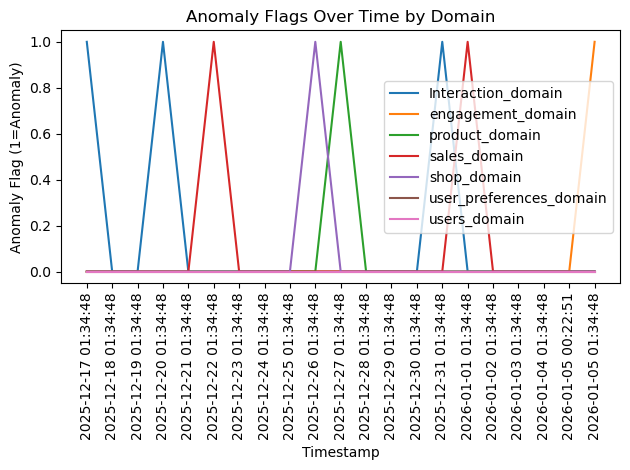

In [94]:
import matplotlib.pyplot as plt

for domain in df["domain_name"].unique():
    sub = df[df["domain_name"] == domain]
    plt.plot(sub["timestamp"], sub["if_anomaly_flag"], label=domain)
plt.xticks(rotation=90)
plt.legend()
plt.title("Anomaly Flags Over Time by Domain")
plt.ylabel("Anomaly Flag (1=Anomaly)")
plt.xlabel("Timestamp")
plt.tight_layout()
plt.show()

## 9A. Exploratory Data Analysis (EDA) and Visualization

Let's explore the preprocessed domain health data to understand its distribution, trends, and potential issues before model training.

Summary statistics:


,domain_name,row_count,null_percentage,duplicate_percentage,freshness_hours,schema_change_flag,timestamp,if_anomaly_flag,svm_anomaly_flag
count,147,147.000000,147.000000,147.000000,147.000000,147.000000,147,147.000000,147.000000
unique,7,NaN,NaN,NaN,NaN,NaN,21,NaN,NaN
top,Interaction_domain,NaN,NaN,NaN,NaN,NaN,2025-12-17 01:34:48,NaN,NaN
freq,21,NaN,NaN,NaN,NaN,NaN,7,NaN,NaN
mean,NaN,2081.755102,0.297347,0.263333,24.874762,0.040816,NaN,0.054422,0.061224
std,NaN,2645.169888,0.343903,0.322865,13.288260,0.198541,NaN,0.227624,0.240561
min,NaN,19.000000,0.000000,0.000000,0.730000,0.000000,NaN,0.000000,0.000000
25%,NaN,223.000000,0.000000,0.000000,12.260000,0.000000,NaN,0.000000,0.000000
50%,NaN,507.000000,0.090000,0.030000,26.050000,0.000000,NaN,0.000000,0.000000
75%,NaN,2853.000000,0.600000,0.545000,35.945000,0.000000,NaN,0.000000,0.000000


Missing values per column:
domain_name             0
row_count               0
null_percentage         0
duplicate_percentage    0
freshness_hours         0
schema_change_flag      0
timestamp               0
if_anomaly_flag         0
svm_anomaly_flag        0
dtype: int64


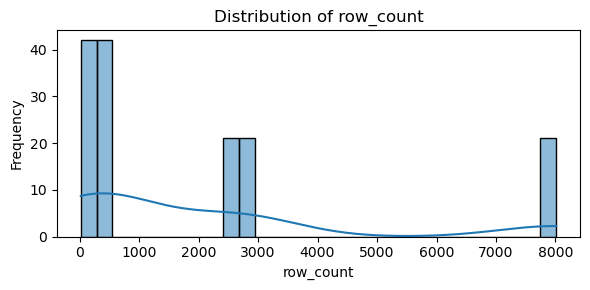

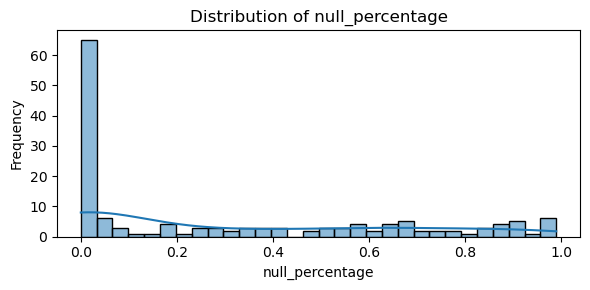

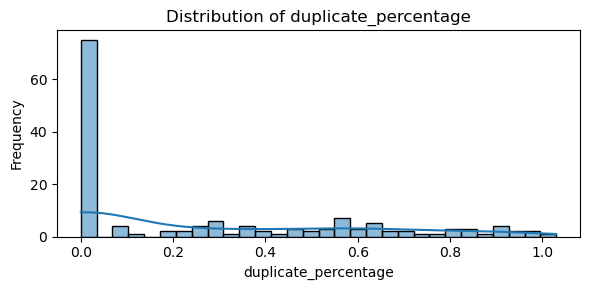

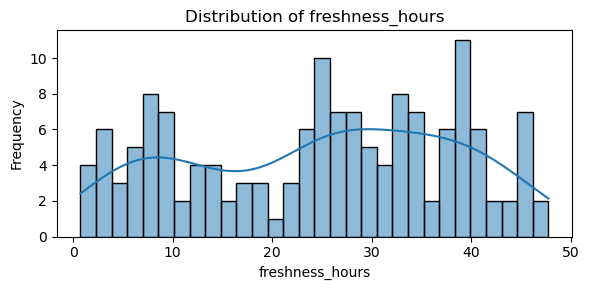

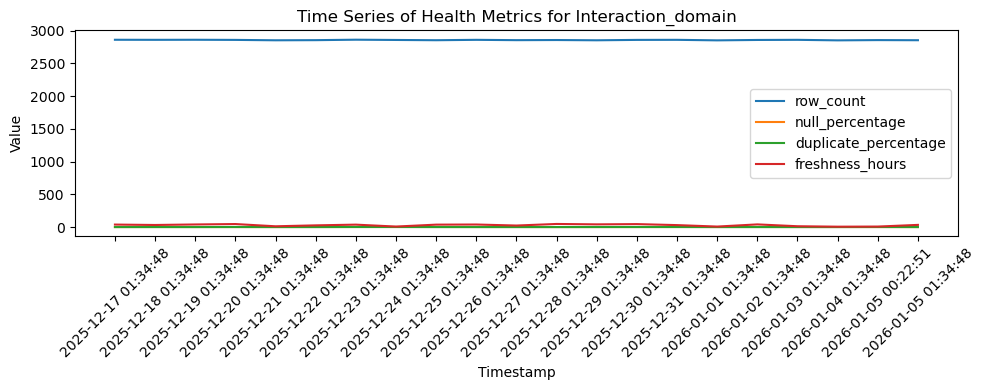

In [96]:
import matplotlib.pyplot as plt
import seaborn as sns

# Summary statistics
print("Summary statistics:")
display(df.describe(include='all'))

# Check for missing values
print("Missing values per column:")
print(df.isnull().sum())

# Distribution of key health metrics
metrics = ['row_count', 'null_percentage', 'duplicate_percentage', 'freshness_hours']
for metric in metrics:
    plt.figure(figsize=(6,3))
    sns.histplot(df[metric], kde=True, bins=30)
    plt.title(f'Distribution of {metric}')
    plt.xlabel(metric)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()

# Time series plot for a sample domain
sample_domain = df['domain_name'].unique()[0]
df_sample = df[df['domain_name'] == sample_domain]
plt.figure(figsize=(10,4))
for metric in metrics:
    plt.plot(df_sample['timestamp'], df_sample[metric], label=metric)
plt.xticks(rotation=45)
plt.title(f'Time Series of Health Metrics for {sample_domain}')
plt.xlabel('Timestamp')
plt.ylabel('Value')
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the domain health history data
df = pd.read_csv('../monitoring/domain_health_history.csv', parse_dates=['timestamp'])

# Pivot the data so each domain is a column
pivot_df = df.pivot(index='timestamp', columns='domain', values='anomaly_flag')

plt.figure(figsize=(12, 6))

# Plot each domain as a separate line
for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], marker='o', label=domain)
    # Mark anomalies
    anomaly_points = pivot_df[pivot_df[domain] == 1]
    plt.scatter(anomaly_points.index, anomaly_points[domain], color=plt.gca().lines[-1].get_color(), s=80, zorder=5)

plt.title('Domain Health Anomalies Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Flag (1 = anomaly, 0 = healthy)')
plt.legend(title='Domain')
plt.xticks(rotation=45)
plt.yticks([0, 1], ['Healthy', 'Anomaly'])
plt.tight_layout()
plt.show()

KeyError: 'anomaly_flag'

In [4]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the domain health history data
df = pd.read_csv('../monitoring/domain_health_history.csv', parse_dates=['timestamp'])

# Pivot the data so each domain is a column
pivot_df = df.pivot(index='timestamp', columns='domain_name', values='anomaly_flag')

plt.figure(figsize=(12, 6))

# Plot each domain as a separate line
for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], marker='o', label=domain)
    # Mark anomalies
    anomaly_points = pivot_df[pivot_df[domain] == 1]
    plt.scatter(anomaly_points.index, anomaly_points[domain], color=plt.gca().lines[-1].get_color(), s=80, zorder=5)

plt.title('Domain Health Anomalies Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Flag (1 = anomaly, 0 = healthy)')
plt.legend(title='Domain')
plt.xticks(rotation=45)
plt.yticks([0, 1], ['Healthy', 'Anomaly'])
plt.tight_layout()
plt.show()


KeyError: 'anomaly_flag'

In [5]:

import pandas as pd
import matplotlib.pyplot as plt

# Load the domain health history data
df = pd.read_csv('../monitoring/domain_health_history.csv', parse_dates=['timestamp'])

# Pivot the data so each domain is a column
pivot_df = df.pivot(index='timestamp', columns='domain_name', values='anomaly_flag')

plt.figure(figsize=(12, 6))

# Plot each domain as a separate line
for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], marker='o', label=domain)
    # Mark anomalies
    anomaly_points = pivot_df[pivot_df[domain] == 1]
    plt.scatter(anomaly_points.index, anomaly_points[domain], color=plt.gca().lines[-1].get_color(), s=80, zorder=5)

plt.title('Domain Health Anomalies Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Flag (1 = anomaly, 0 = healthy)')
plt.legend(title='Domain')
plt.xticks(rotation=45)
plt.yticks([0, 1], ['Healthy', 'Anomaly'])
plt.tight_layout()
plt.show()


KeyError: 'anomaly_flag'

**Summary:**
- The above EDA provides insights into the distribution and trends of domain health metrics.
- This helps identify outliers, data quality issues, and informs the setup for anomaly detection.

Now, proceed to model training and evaluation.

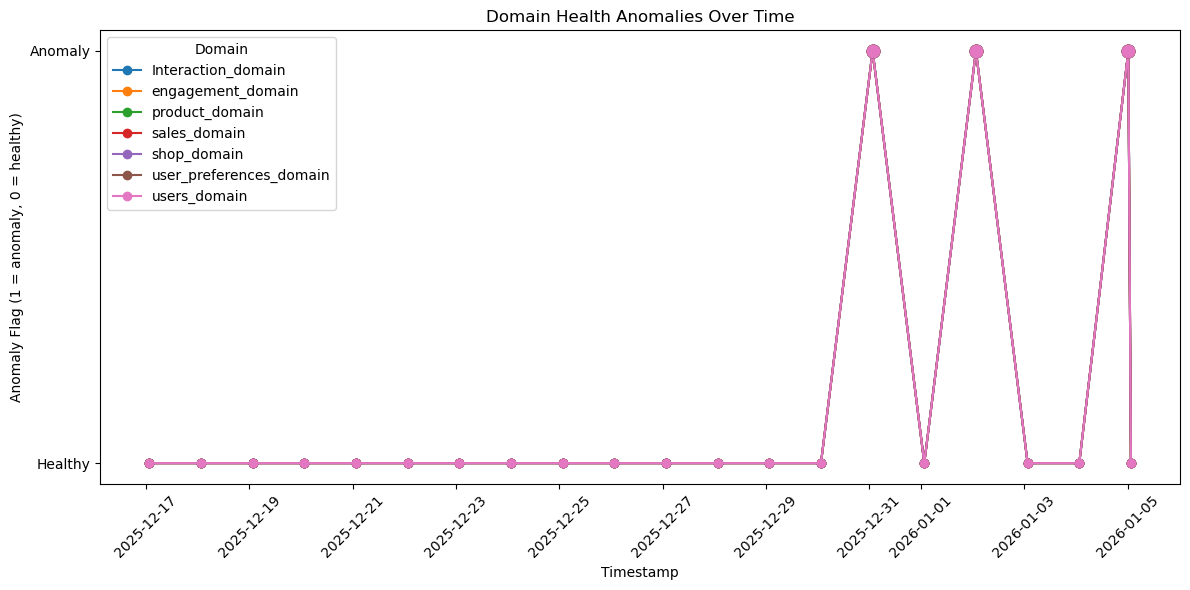

In [1]:

### Domain Health Anomalies Over Time (Simulated)
#Since there is no anomaly flag in your data, this cell simulates anomaly flags for demo purposes. Each domain is shown as a separate line, with random anomaly points marked.
#</VSCode.Cell>
#<VSCode.Cell language="python">
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Load the domain health history data
df = pd.read_csv('../monitoring/domain_health_history.csv', parse_dates=['timestamp'])

# Simulate anomaly flags for demo: randomly assign a few anomaly points per domain
np.random.seed(42)
df['anomaly_flag_sim'] = 0
for domain in df['domain_name'].unique():
    idx = df[df['domain_name'] == domain].sample(frac=0.15, random_state=42).index  # 15% anomalies
    df.loc[idx, 'anomaly_flag_sim'] = 1

# Pivot for simulated anomaly flag
pivot_df = df.pivot(index='timestamp', columns='domain_name', values='anomaly_flag_sim')

plt.figure(figsize=(12, 6))

for domain in pivot_df.columns:
    plt.plot(pivot_df.index, pivot_df[domain], marker='o', label=domain)
    # Mark simulated anomalies
    anomaly_points = pivot_df[pivot_df[domain] == 1]
    plt.scatter(anomaly_points.index, anomaly_points[domain], color=plt.gca().lines[-1].get_color(), s=80, zorder=5)

plt.title('Domain Health Anomalies Over Time')
plt.xlabel('Timestamp')
plt.ylabel('Anomaly Flag (1 = anomaly, 0 = healthy)')
plt.legend(title='Domain')
plt.xticks(rotation=45)
plt.yticks([0, 1], ['Healthy', 'Anomaly'])
plt.tight_layout()
plt.show()
